<a href="https://colab.research.google.com/github/Atharva6907/ML-Practice-Projects/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ALL THE BEST

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.datasets import fetch_california_housing

In [ ]:
california = fetch_california_housing()

In [ ]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [ ]:
pd.set_option('display.precision', 4)
california_df = pd.DataFrame(california.data, columns=california.feature_names)

In [ ]:
california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25


In [ ]:
california_df.size

165120

In [ ]:
california_df.shape

(20640, 8)

In [ ]:
california_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100


In [ ]:
california_df['MedHouseValue'] = pd.Series(california.target)
correlation = california_df.corr()

<Axes: >

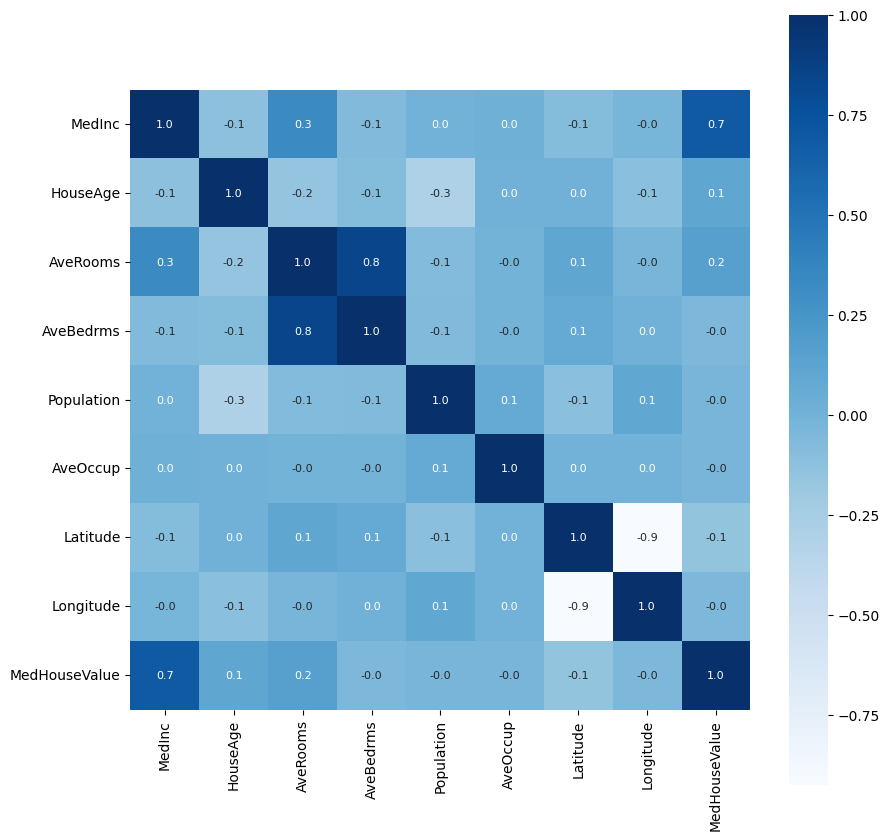

In [ ]:
# constructing a heatmap to nderstand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [ ]:
sample_df = california_df.sample(frac=0.1, random_state=17)
print(sample_df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
18403  5.4741      24.0    6.5878     1.0602      4017.0    3.3116     37.24   
13405  1.9583       7.0    5.3628     1.4421      1064.0    3.2439     34.10   
9539   2.6058      40.0    3.8857     0.9143       785.0    4.4857     37.39   
8668   4.5817      30.0    4.1461     1.1087      1526.0    1.8430     33.82   
9019   8.0137       9.0    7.7347     1.0412     12873.0    3.2747     34.16   
...       ...       ...       ...        ...         ...       ...       ...   
19279  1.9458      26.0    4.7097     1.0202       937.0    3.7782     38.42   
12378  1.3801      25.0    4.7375     1.7250       604.0    2.5167     33.78   
16068  3.7361      48.0    5.7546     1.1055      1041.0    2.7467     37.75   
16563  5.0176      19.0    6.0615     0.9564      1264.0    3.2410     37.77   
12071  5.2898      25.0    6.7220     1.0290      3240.0    3.1274     33.86   

       Longitude  MedHouseValue  
18403

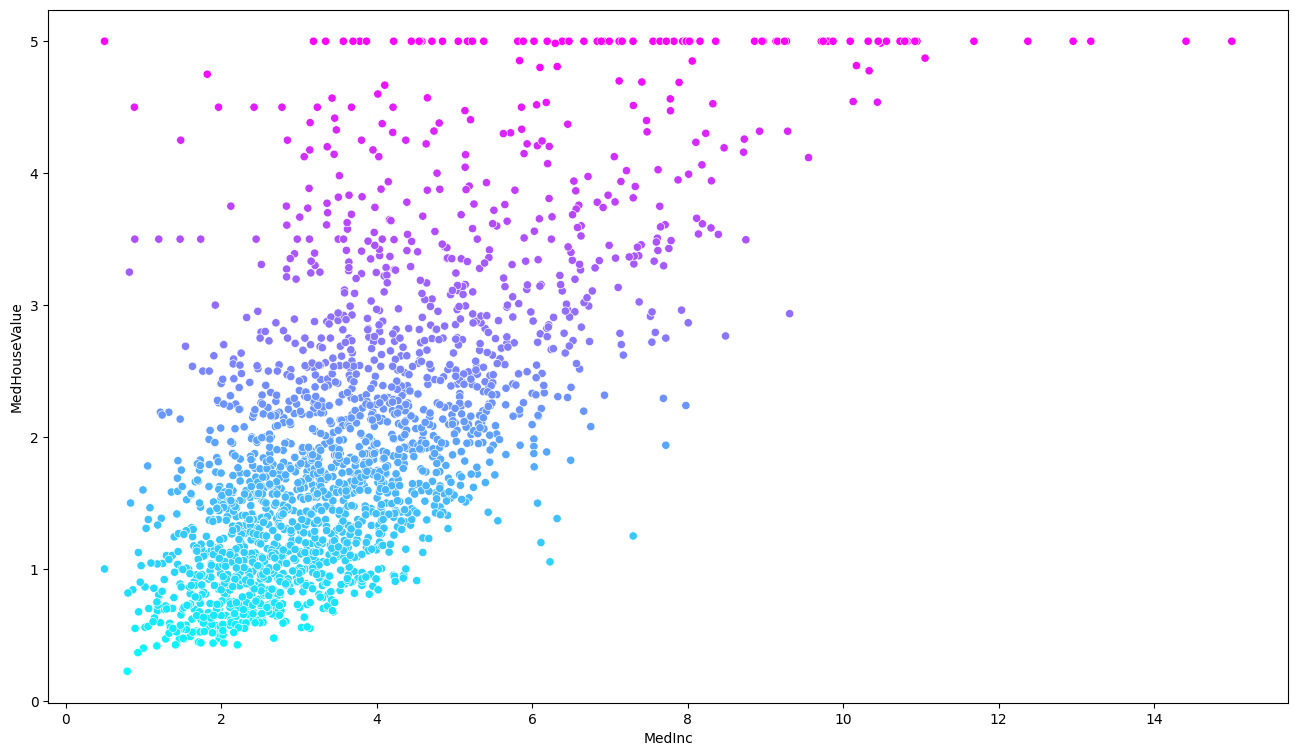

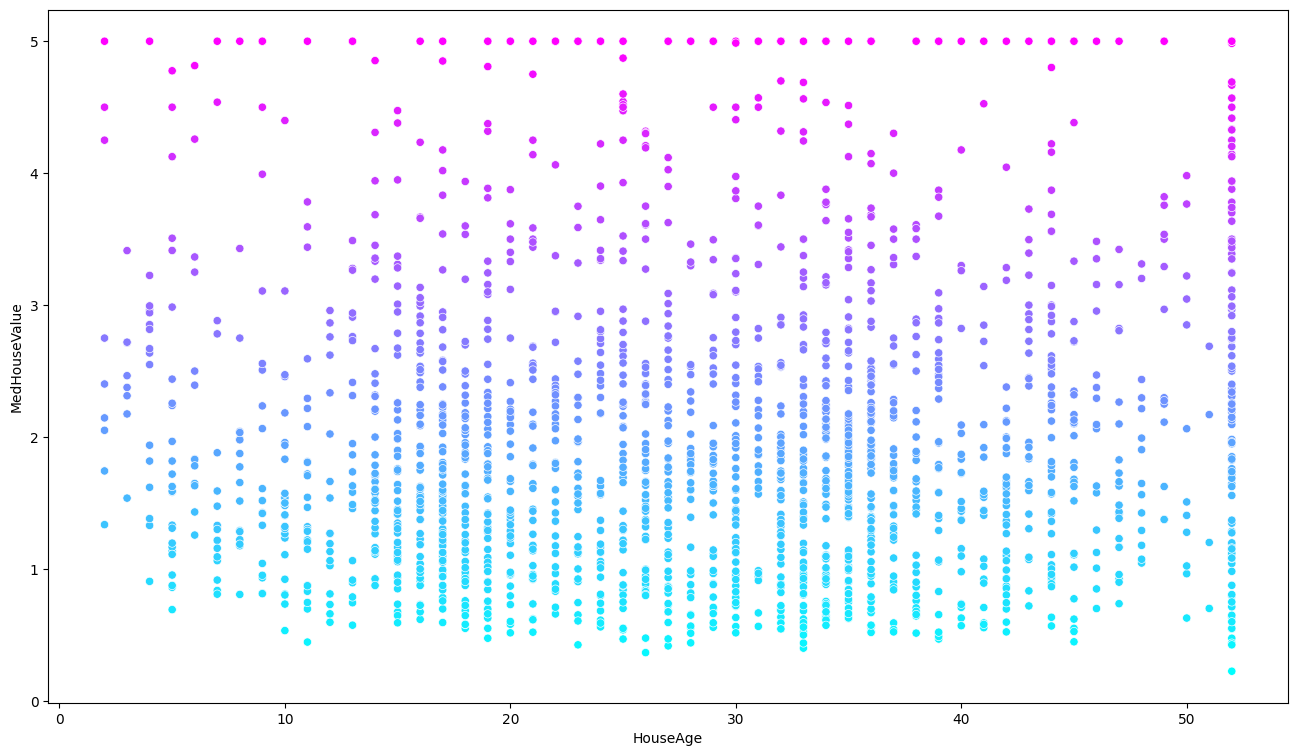

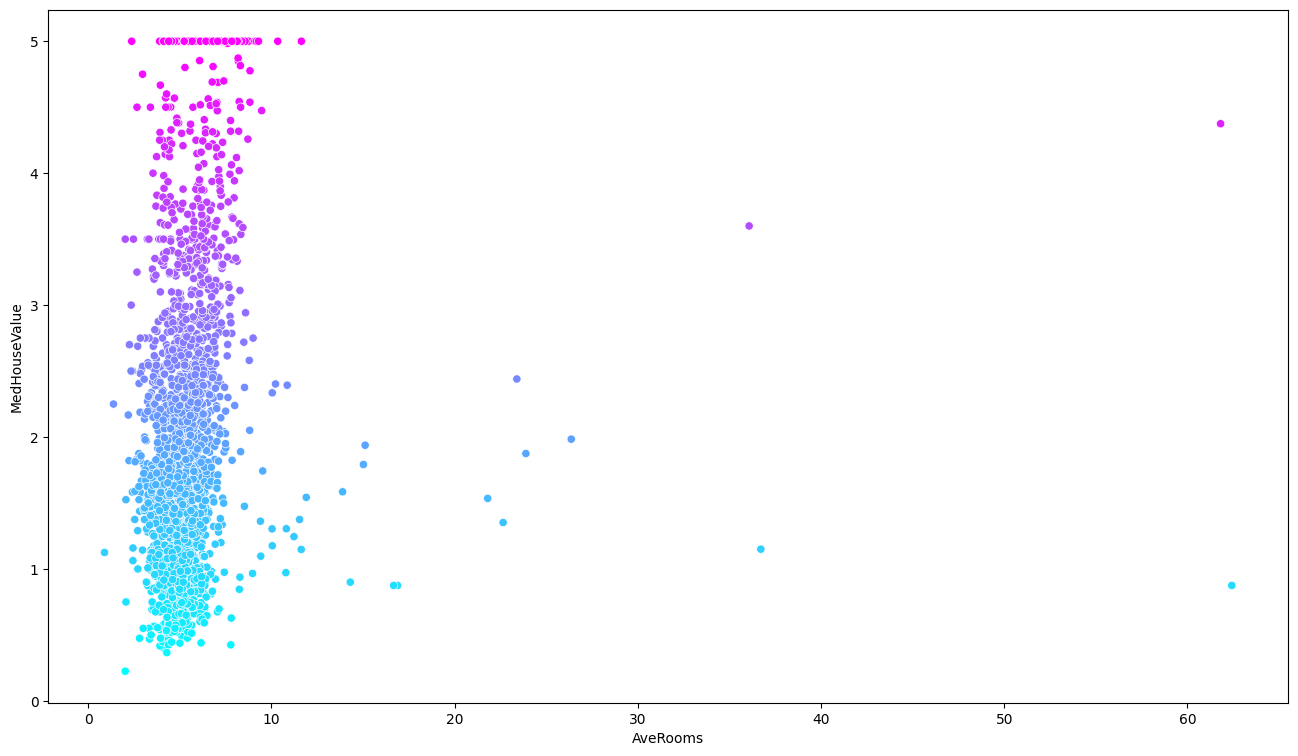

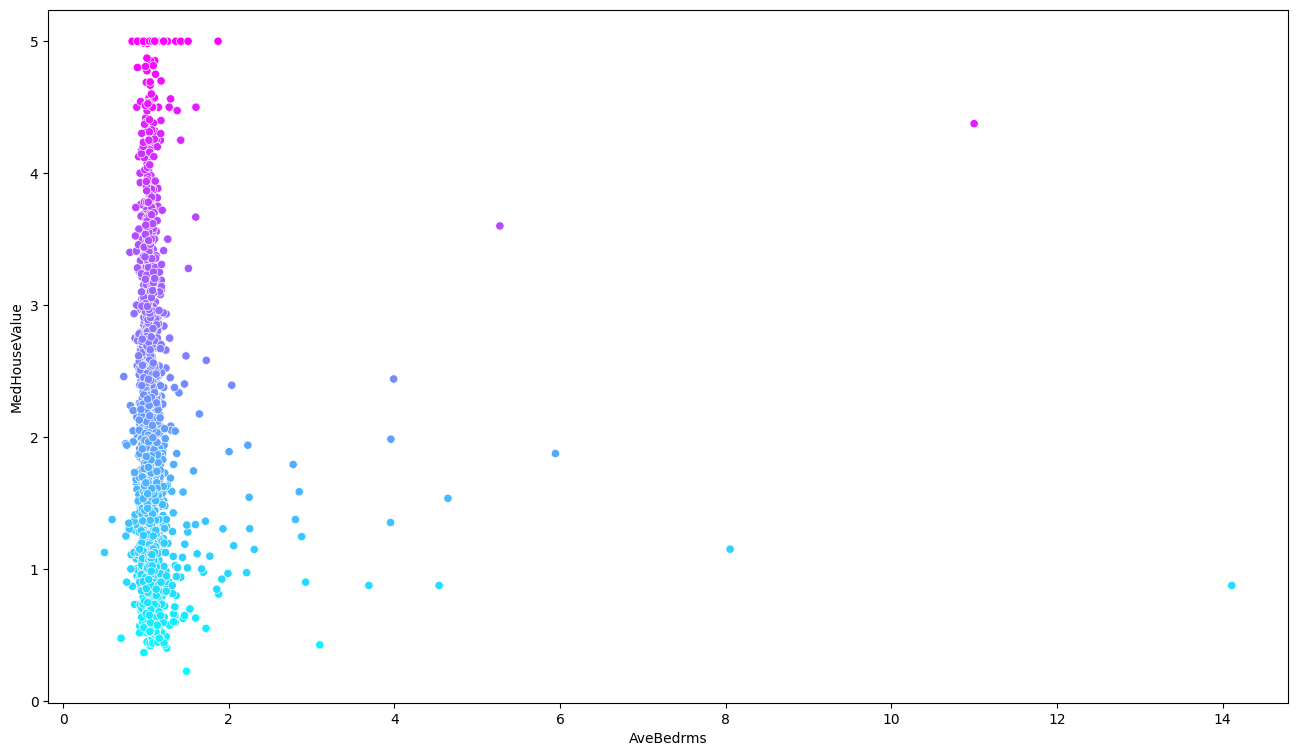

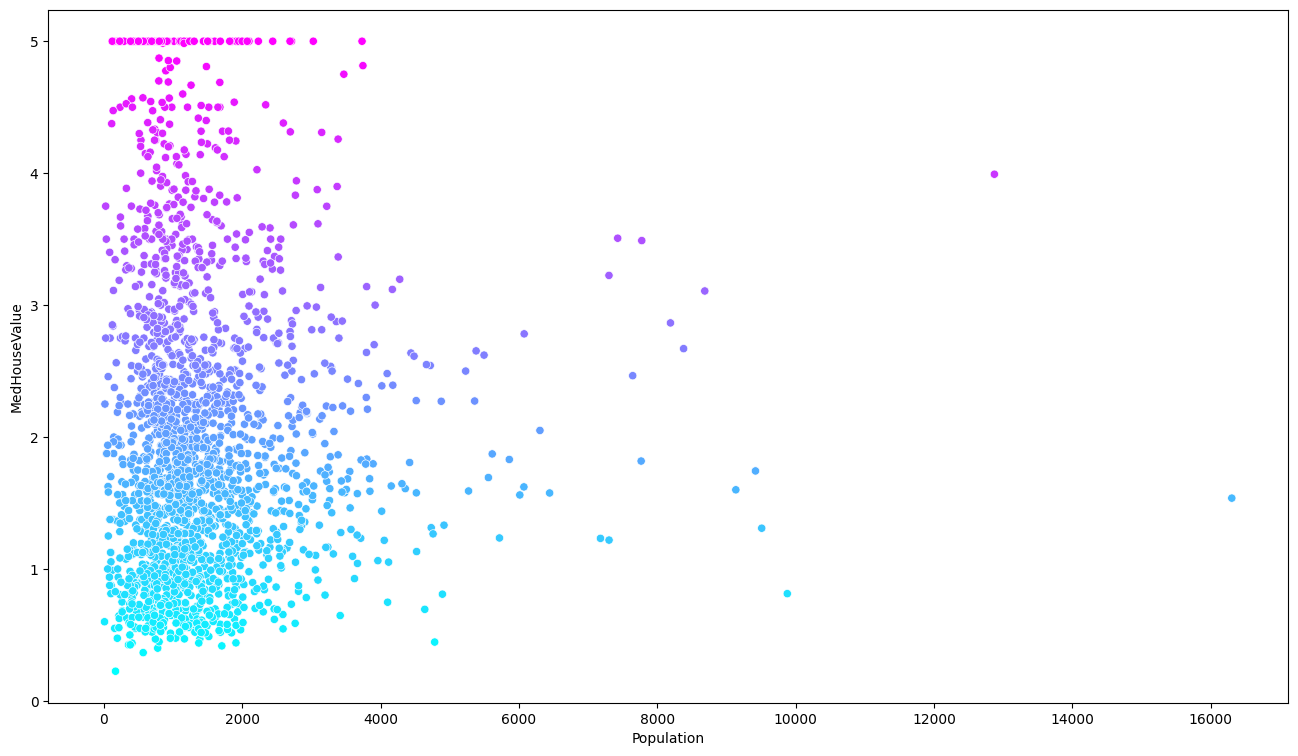

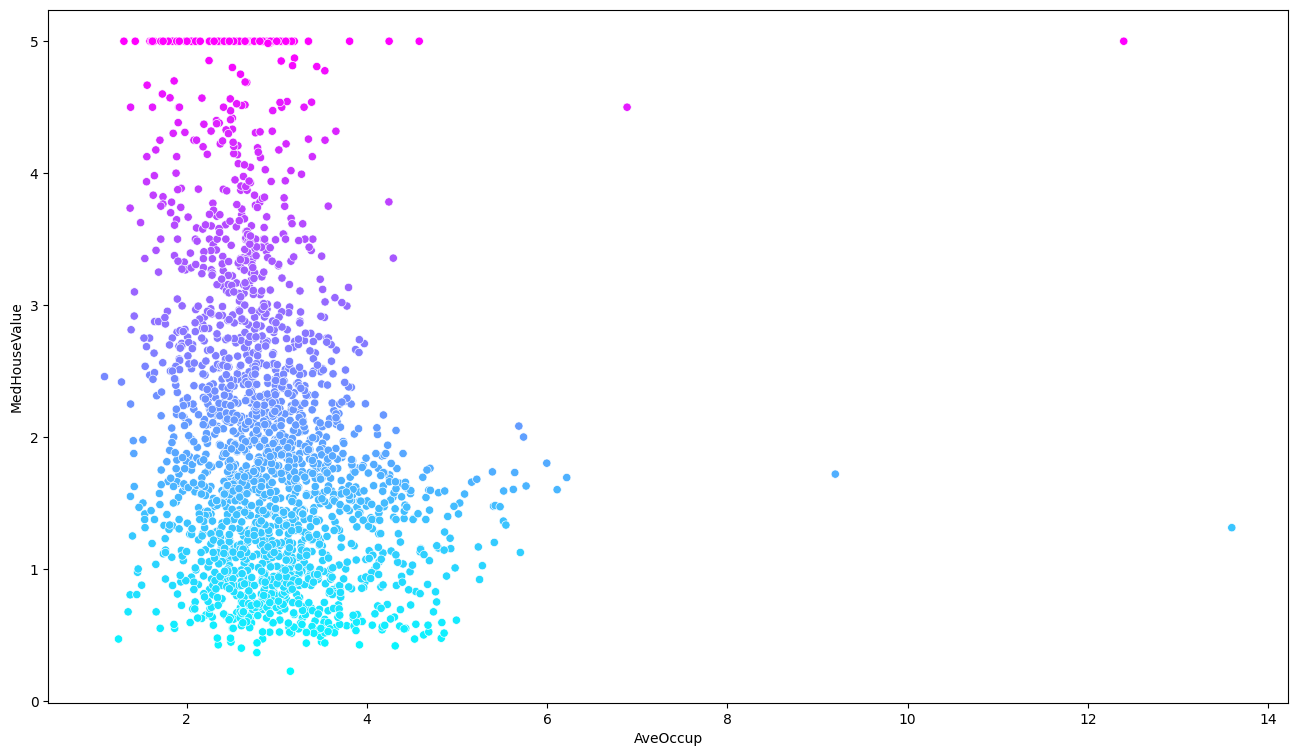

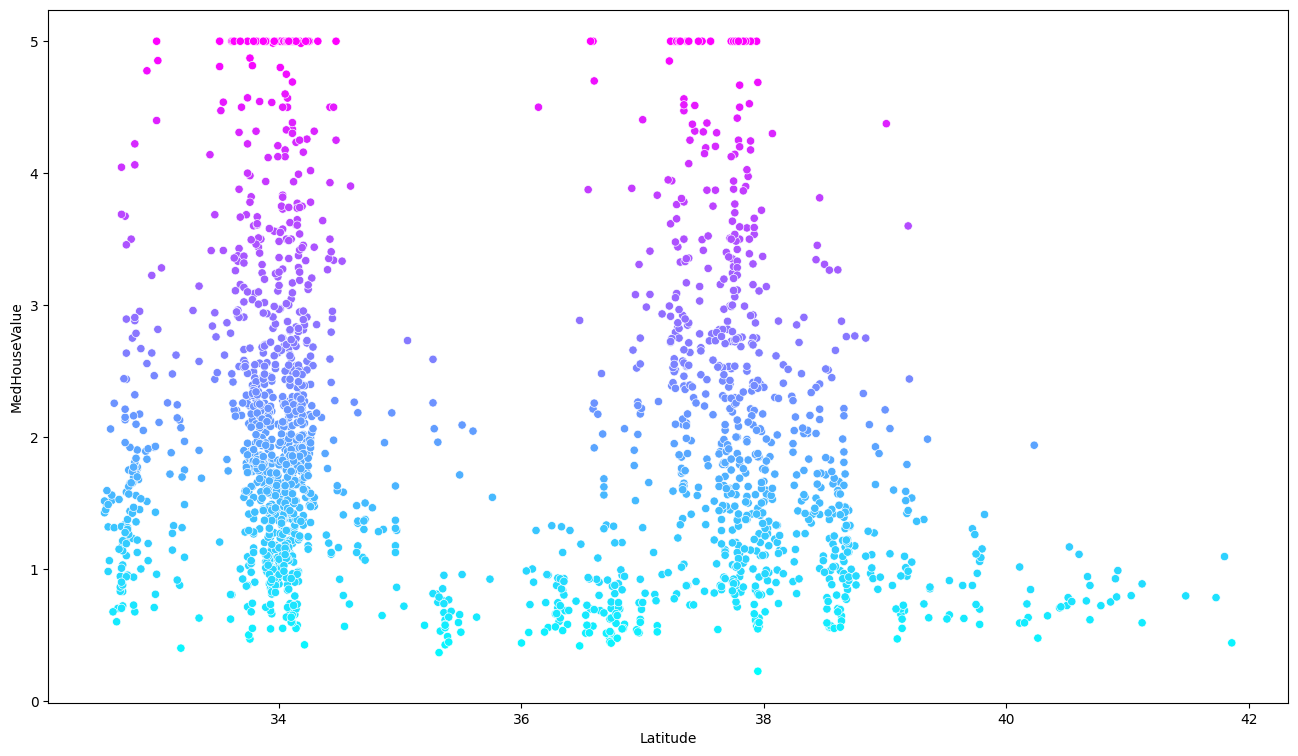

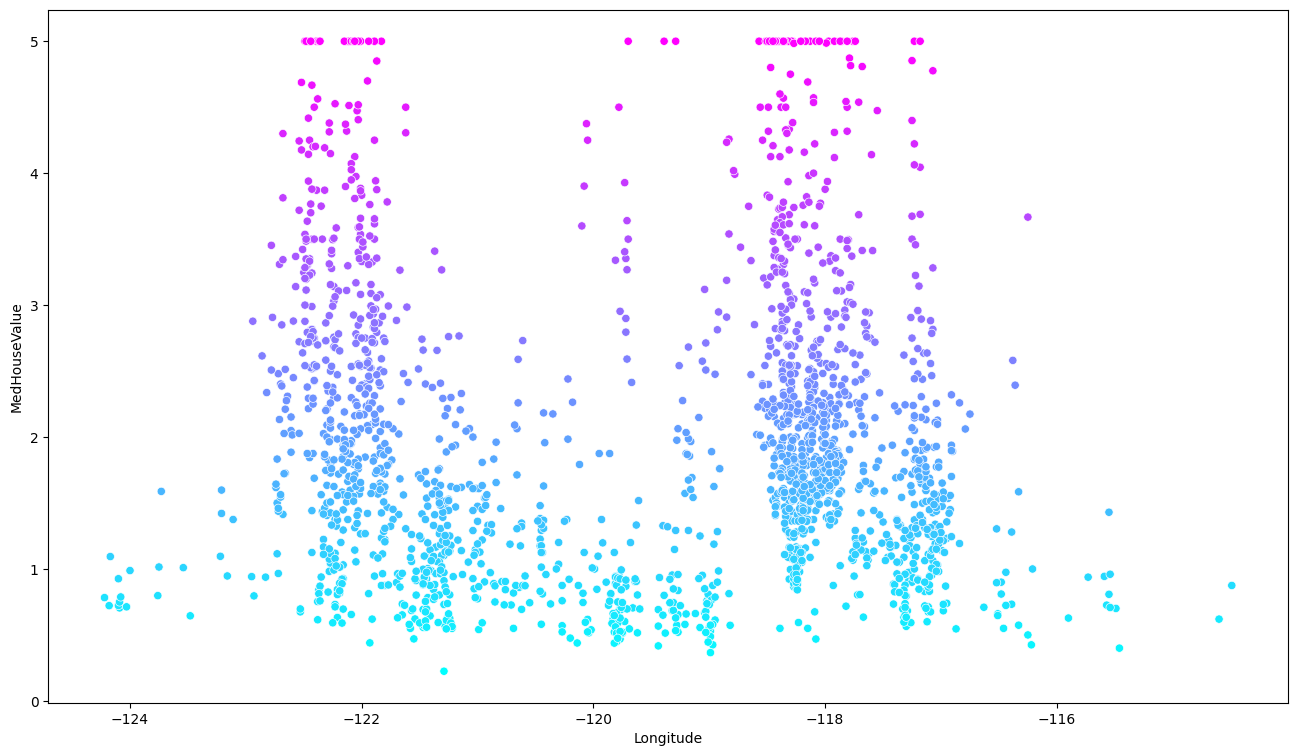

In [ ]:
for feature in california.feature_names:
    plt.figure(figsize=(16,9))
    sns.scatterplot(data=sample_df, x=feature,y='MedHouseValue',
                    hue='MedHouseValue', palette='cool', legend=False)

In [ ]:
california_df['bedrooms_per_room'] = california_df['AveBedrms'] / california_df['AveRooms']

In [ ]:
california_df.drop(columns=['AveBedrms', 'AveRooms'], inplace=True)

In [ ]:
california_df.head()

,MedInc,HouseAge,Population,AveOccup,Latitude,Longitude,MedHouseValue,bedrooms_per_room
0,8.3252,41.0,322.0,2.5556,37.88,-122.23,4.526,0.1466
1,8.3014,21.0,2401.0,2.1098,37.86,-122.22,3.585,0.1558
2,7.2574,52.0,496.0,2.8023,37.85,-122.24,3.521,0.1295
3,5.6431,52.0,558.0,2.5479,37.85,-122.25,3.413,0.1845
4,3.8462,52.0,565.0,2.1815,37.85,-122.25,3.422,0.1721


In [ ]:
from sklearn.model_selection import train_test_split
X = california_df.drop('MedHouseValue', axis = 1)
y = california.target
X_train, X_test, y_train, y_test = train_test_split(X , california.target, random_state = 42)

In [ ]:
X_train.head()

,MedInc,HouseAge,Population,AveOccup,Latitude,Longitude,bedrooms_per_room
8158,4.2143,37.0,860.0,2.5294,33.81,-118.12,0.1841
18368,5.3468,42.0,957.0,2.4045,37.16,-121.98,0.1709
19197,3.9191,36.0,711.0,2.2358,38.45,-122.69,0.1734
3746,6.3703,32.0,1159.0,2.2725,34.16,-118.41,0.1650
13073,2.3684,17.0,706.0,2.0888,38.57,-121.33,0.2159


In [ ]:
X_train.shape

(15480, 7)

In [ ]:
X_test.shape

(5160, 7)

In [ ]:
#MODEL NUMBER 1: LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
predicted = linear_regression.predict(X_test)
expected = y_test

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
print(f'The R2 score: {r2_score(expected, predicted)}')
print(f'The MSE: {mean_squared_error(expected, predicted)}')

The R2 score: 0.6068520206660734
The MSE: 0.5202205241646596


In [ ]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

estimators = {
    'LinearRegression': linear_regression,
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()}

from sklearn.model_selection import KFold, cross_val_score

for estimator_name, estimator_object in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator_object,
                             X=california.data, y=california.target, cv=kfold,
                             scoring='r2')
    print(f'{estimator_name:>16}: ' +
          f'mean of r2 scores={scores.mean():.3f}')

LinearRegression: mean of r2 scores=0.599
      ElasticNet: mean of r2 scores=0.423
           Lasso: mean of r2 scores=0.285
           Ridge: mean of r2 scores=0.599


In [ ]:
model1 = Ridge()
model1.fit(california.data, california.target)
best_predicted = linear_regression.predict(X_test)

In [ ]:
print(f'The R2 score: {r2_score(expected, best_predicted)}')
print(f'The MSE: {mean_squared_error(expected, best_predicted)}')

The R2 score: 0.6068520206660734
The MSE: 0.5202205241646596


In [ ]:
#MODEL NUMBER 2:XGBoost

In [ ]:
from xgboost import XGBRegressor
model2 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,  # Lower rate for better generalization
    max_depth=5,          # Shallow trees
    subsample=0.8,        # Use 80% of rows per tree
    colsample_bytree=0.8, # Use 80% of features per tree
    reg_lambda=10,        # L2 regularization
    reg_alpha=1,          # L1 regularization
    random_state=42)
model2.fit(X_train, y_train,eval_set=[(X_test, y_test)])

[0]	validation_0-rmse:1.11817
[1]	validation_0-rmse:1.09886
[2]	validation_0-rmse:1.06766
[3]	validation_0-rmse:1.03850
[4]	validation_0-rmse:1.01143
[5]	validation_0-rmse:0.99134
[6]	validation_0-rmse:0.97285
[7]	validation_0-rmse:0.95114
[8]	validation_0-rmse:0.92908
[9]	validation_0-rmse:0.90856
[10]	validation_0-rmse:0.88944
[11]	validation_0-rmse:0.87601
[12]	validation_0-rmse:0.85777
[13]	validation_0-rmse:0.84135
[14]	validation_0-rmse:0.82611
[15]	validation_0-rmse:0.81057
[16]	validation_0-rmse:0.79635
[17]	validation_0-rmse:0.78612
[18]	validation_0-rmse:0.77388
[19]	validation_0-rmse:0.76362
[20]	validation_0-rmse:0.75384
[21]	validation_0-rmse:0.74579
[22]	validation_0-rmse:0.73702
[23]	validation_0-rmse:0.72779
[24]	validation_0-rmse:0.71923
[25]	validation_0-rmse:0.71012
[26]	validation_0-rmse:0.70155
[27]	validation_0-rmse:0.69409
[28]	validation_0-rmse:0.68568
[29]	validation_0-rmse:0.67860
[30]	validation_0-rmse:0.67135
[31]	validation_0-rmse:0.66578
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
training_data_prediction = model2.predict(X_train)

In [ ]:
score_1 = metrics.r2_score(y_train, training_data_prediction)

score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.921650273659183
Mean Absolute Error :  0.22243593069170553


In [ ]:
test_data_prediction = model2.predict(X_test)
score_1 = metrics.r2_score(y_test, test_data_prediction)

score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8495332017644834
Mean Absolute Error :  0.2923295447709967


In [ ]:
#MODEL NUMBER 3: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model3 = RandomForestRegressor(
    n_estimators=500,      # More trees for better averaging
    max_depth=15,          # Limit depth
    min_samples_leaf=10,   # Ensure leaves aren't too small
    max_features='sqrt',   # Force feature diversity
    bootstrap=True,        # Ensure bagging is active
    n_jobs=-1,
    random_state=42)
model3.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=10,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
y_pred = model3.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 0.2745
R2 Score: 0.7926


In [ ]:
# ENSEMBLING THE MODELS

In [ ]:
from sklearn.ensemble import StackingRegressor
ensembled_model = StackingRegressor(
    estimators = [('lr',linear_regression), ('xgb', model2), ('rf', model3)],
    final_estimator = LinearRegression()
    )

ensembled_model.fit(X_train, y_train)

stacked_preds = ensembled_model.predict(X_test)
print(f"Stacking R2 Score: {r2_score(y_test, stacked_preds):.4f}")

Stacking R2 Score: 0.8497


In [ ]:
train_score = ensembled_model.score(X_train, y_train)
test_score = ensembled_model.score(X_test, y_test)

print(f"Train R2: {train_score:.4f}")
print(f"Test R2: {test_score:.4f}")
print(f"Difference: {train_score - test_score:.4f}")

Train R2: 0.9223
Test R2: 0.8497
Difference: 0.0725
